# Gelismis Stacking Regressor ve Kumeleme Analizi

Bu proje, yuksek performansli bir regresyon pipeline'i kurar. Sadece model egitmiyoruz; verideki gizli desenleri yakalamak icin Denetimsiz Ogrenme (Clustering) kullanarak ozellik muhendisligi yapiyoruz.


**Ogrenci :** Ramazan Bozkurt  
**Proje :** Arac Fiyat Tahmin  
**Ogrenci No :** 22040301027  

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, max_error

# Grafik Ayarlari
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Ozel Bilesen: Sizintisiz Kumeleme (Leakage-Free Clustering)

Standart kumeleme yontemleri egitim ve test verisini bir arada gordugunde veri sizintisi yasanir. Bu sinif, kume merkezlerini sadece egitim setinden ogrenir.

Ayrica Agglomerative Clustering normalde yeni gelen veriyi tahmin edemez. Burada KNN kullanarak bu sorunu cozuyoruz.

In [2]:
class ClusterFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=6, strategy='kmeans'):
        self.n_clusters = n_clusters
        self.strategy = strategy
        self.clusterer = None
        self.knn = None

    def fit(self, X, y=None):
        # Verini yapısını sadece eğitim setinden öğrenmesini sağlıyoruz
        if self.strategy == 'kmeans':
            self.clusterer = KMeans(n_clusters=self.n_clusters, random_state=42, n_init=10)
            self.clusterer.fit(X)
        else: # Agglomerative
            self.clusterer = AgglomerativeClustering(n_clusters=self.n_clusters)
            labels = self.clusterer.fit_predict(X)
            # Tahmin yetenegi kazandirmak icin KNN egitimi
            self.knn = KNeighborsClassifier(n_neighbors=1)
            self.knn.fit(X, labels)
        return self

    def transform(self, X):
        if self.strategy == 'kmeans':
            clusters = self.clusterer.predict(X)
        else:
            clusters = self.knn.predict(X)
        return clusters.reshape(-1, 1).astype(str)

## 2. Veri Hazirligi ve Hedef Degisken Analizi

Veriyi modele sokmadan once, neyi tahmin etmeye calistigimizi gormeliyiz. Fiyat verisi genellikle saga carpiktir, bu yuzden Logaritma donusumu uyguluyoruz.

In [3]:
print("-> Veri yukleniyor...")
try:
    df = pd.read_csv('cleaned_data.csv')
except FileNotFoundError:
    print("HATA: 'cleaned_data.csv' dosyasi bulunamadi.")

# String Temizligi
df['model'] = df['model'].str.strip()
df['marka'] = df['marka'].str.strip()

X = df.drop('price', axis=1)
y_raw = df['price']
y = np.log1p(y_raw)

numeric_features = ['mileage', 'tax', 'mpg', 'engine_size', 'car_age']
categorical_features = ['marka', 'model', 'transmission', 'fuel_type']

# KRITIK ADIM: Once Egitim/Test ayrini yapiyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"-> Egitim Seti: {X_train.shape[0]} satir, Test Seti: {X_test.shape[0]} satir")

-> Veri yukleniyor...
-> Egitim Seti: 23972 satir, Test Seti: 5993 satir


### Grafik 1: Hedef Degisken Dagilimi
Asagidaki grafik, neden Log donusumu yaptigimizi kanitlar niteliktedir. Orijinal fiyat dagilimi dengesizken, Log alinmis hali modele daha uygundur.

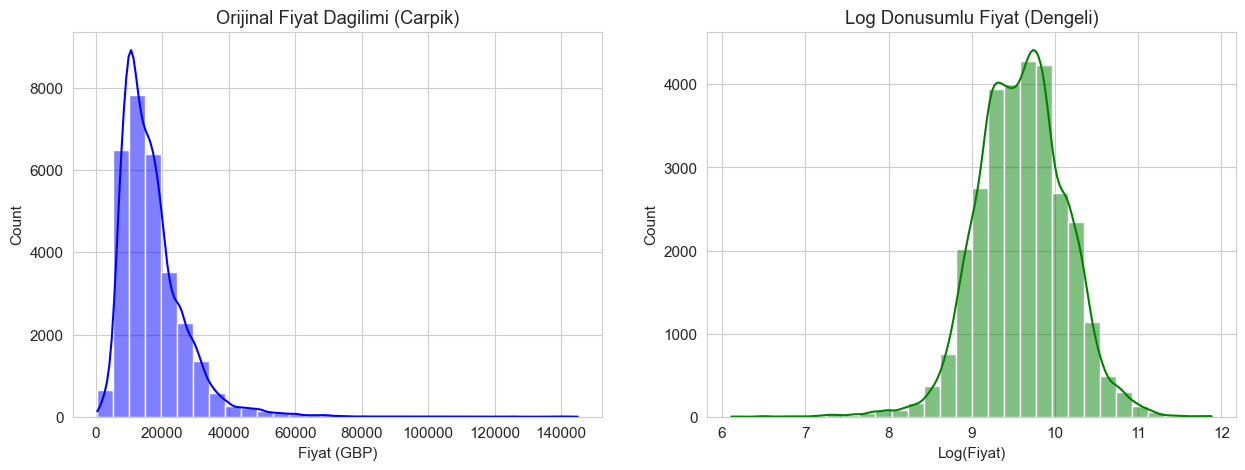

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Orijinal Fiyatlar
sns.histplot(y_raw, kde=True, ax=ax[0], color='blue', bins=30)
ax[0].set_title('Orijinal Fiyat Dagilimi (Carpik)')
ax[0].set_xlabel('Fiyat (GBP)')

# Log Fiyatlar
sns.histplot(y, kde=True, ax=ax[1], color='green', bins=30)
ax[1].set_title('Log Donusumlu Fiyat (Dengeli)')
ax[1].set_xlabel('Log(Fiyat)')

plt.show()

## 3. Stacking Pipeline Mimarisi

Burada karmasik bir pipeline kuruyoruz. XGBoost ve Random Forest ana tahminleyiciler olarak calisirken, son karari Ridge Regresyon (Meta-Learner) veriyor.

In [5]:
def get_stacking_pipeline(strategy=None):
    # Temel Donusturuculer
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # sparse_output=False, XGBoost ve RF uyumlulugu icin sarttir
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    transformers = [
        ('num', num_pipe, numeric_features),
        ('cat', cat_pipe, categorical_features)
    ]
    
    # Eger strateji secilmisse Kumeleme ekle
    if strategy:
        cluster_pipe = Pipeline([
            ('num_prep', num_pipe),
            ('extractor', ClusterFeatureExtractor(n_clusters=6, strategy=strategy)),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
        transformers.append(('clusters', cluster_pipe, numeric_features))

    preprocessor = ColumnTransformer(transformers=transformers)

    # Ana Modeller (Base Learners)
    estimators = [
        ('xgb', xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, n_jobs=-1, random_state=42)),
        ('rf', RandomForestRegressor(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42)),
        ('ridge', Ridge(alpha=1.0))
    ]

    # Stacking Regressor (Meta-Learner: RidgeCV)
    stacking_model = StackingRegressor(
        estimators=estimators,
        final_estimator=RidgeCV(),
        cv=5,
        n_jobs=-1,
        passthrough=False
    )

    return Pipeline([
        ('prep', preprocessor),
        ('reg', stacking_model)
    ])

## 4. Senaryolarin Kosturulmasi

Uc farkli senaryoyu test edecegiz:
1.  **Base Stacking:** Sadece standart ozellikler.
2.  **Stacking + KMeans:** Geometrik kumeleme ozellikleri eklenmis.
3.  **Stacking + Agglomerative:** Hiyerarsik kumeleme ozellikleri eklenmis.

In [6]:
def calculate_metrics(y_test_log, y_pred_log, X_test, model_name, duration):
    y_test_real = np.expm1(y_test_log)
    y_pred_real = np.expm1(y_pred_log)
    
    mae = mean_absolute_error(y_test_real, y_pred_real)
    mse = mean_squared_error(y_test_real, y_pred_real)
    r2 = r2_score(y_test_log, y_pred_log)
    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100
    max_err = max_error(y_test_real, y_pred_real)
    
    return {
        'Senaryo': model_name,
        'R2': r2,
        'MAE (GBP)': mae,
        'RMSE (GBP)': np.sqrt(mse),
        'MAPE (%)': mape,
        'Max Hata': max_err,
        'Sure (sn)': duration
    }

strategies = [None, 'kmeans', 'agglomerative']
all_results = []
predictions = {} # Cizimler icin tahminleri sakliyoruz

print("Model egitim sureci basliyor...")

for strategy in strategies:
    s_name = "Base Stacking" if strategy is None else f"Stacking + {strategy.capitalize()}"
    print(f"-> Calistiriliyor: {s_name}...")
    
    start_time = time.time()
    
    model = get_stacking_pipeline(strategy)
    model.fit(X_train, y_train)
    
    y_pred_log = model.predict(X_test)
    predictions[s_name] = y_pred_log
    
    elapsed = time.time() - start_time
    metrics = calculate_metrics(y_test, y_pred_log, X_test, s_name, elapsed)
    all_results.append(metrics)

results_df = pd.DataFrame(all_results)
print("\nTum senaryolar tamamlandi.")

Model egitim sureci basliyor...
-> Calistiriliyor: Base Stacking...
-> Calistiriliyor: Stacking + Kmeans...
-> Calistiriliyor: Stacking + Agglomerative...

Tum senaryolar tamamlandi.


### Grafik 2: Performans Karsilastirmasi
Hangi model daha iyi? R2 skoru (yuksek olmali) ve Hata orani (dusuk olmali) uzerinden karsilastiralim.

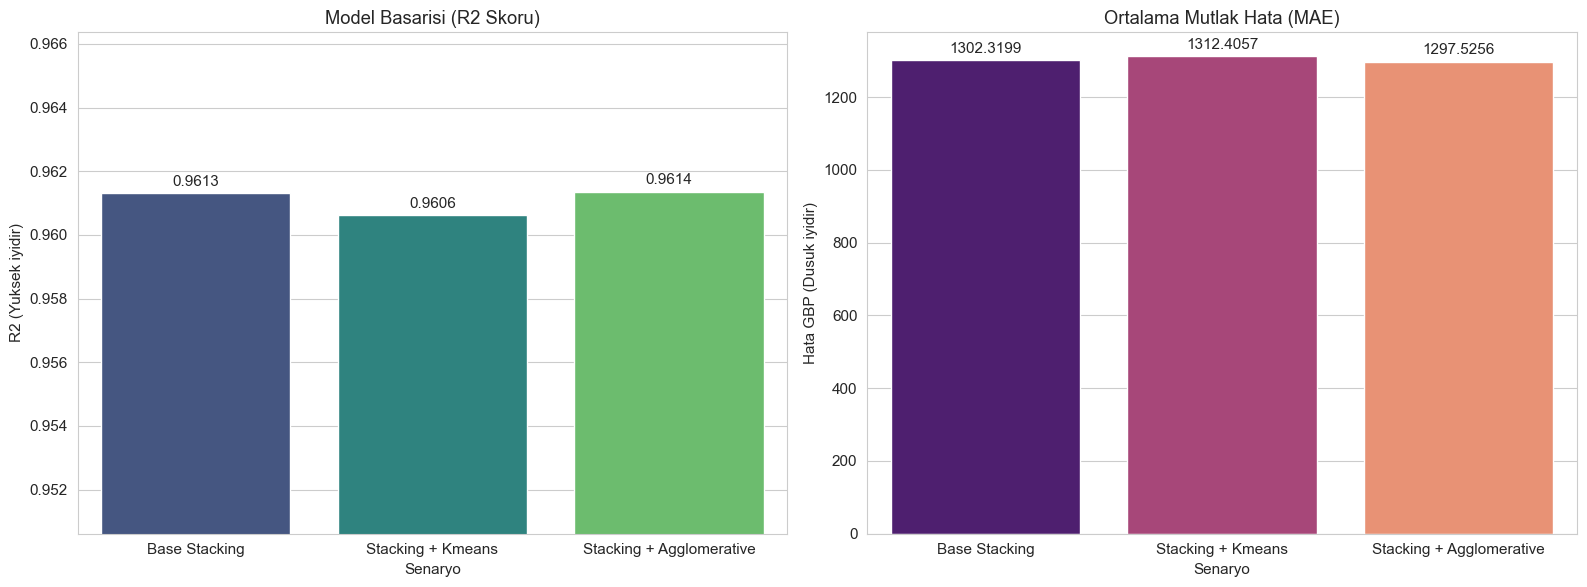

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# R2 Skoru Karsilastirmasi
sns.barplot(x='Senaryo', y='R2', data=results_df, ax=ax[0], palette='viridis', hue='Senaryo', legend=False)
ax[0].set_ylim(results_df['R2'].min() - 0.01, results_df['R2'].max() + 0.005)
ax[0].set_title('Model Basarisi (R2 Skoru)')
ax[0].set_ylabel('R2 (Yuksek iyidir)')

# MAE Karsilastirmasi
sns.barplot(x='Senaryo', y='MAE (GBP)', data=results_df, ax=ax[1], palette='magma', hue='Senaryo', legend=False)
ax[1].set_title('Ortalama Mutlak Hata (MAE)')
ax[1].set_ylabel('Hata GBP (Dusuk iyidir)')

for i in range(2):
    for container in ax[i].containers:
        ax[i].bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

### Grafik 3: Gercek vs Tahmin ve Hata Analizi
En iyi performansi gosteren modeli secip detayli inceleyelim. Hatalarin rastgele dagilmasi (desen olusturmamasi) modelin saglikli oldugunu gosterir.

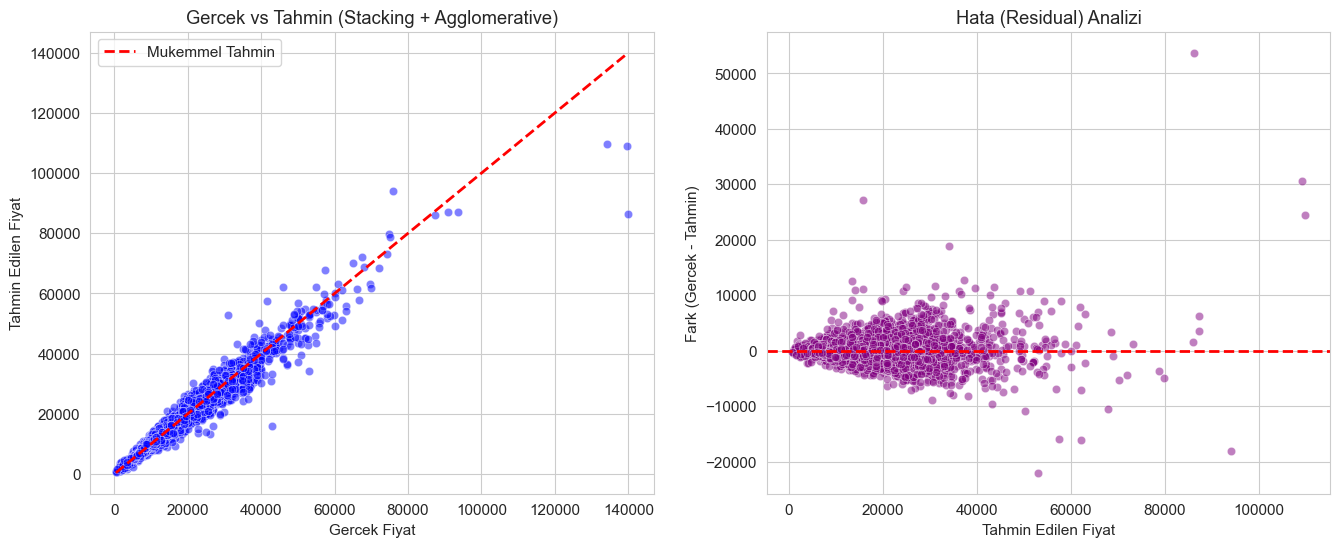

In [9]:
# En iyi modeli bul
best_scenario = results_df.sort_values(by='R2', ascending=False).iloc[0]['Senaryo']
best_preds_log = predictions[best_scenario]

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(best_preds_log)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot: Gercek vs Tahmin
sns.scatterplot(x=y_test_real, y=y_pred_real, alpha=0.5, ax=ax[0], color='blue')
min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())
ax[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Mukemmel Tahmin')
ax[0].set_title(f'Gercek vs Tahmin ({best_scenario})')
ax[0].set_xlabel('Gercek Fiyat')
ax[0].set_ylabel('Tahmin Edilen Fiyat')
ax[0].legend()

# Residual Plot: Hata Dagilimi
residuals = y_test_real - y_pred_real
sns.scatterplot(x=y_pred_real, y=residuals, alpha=0.5, ax=ax[1], color='purple')
ax[1].axhline(0, color='red', linestyle='--', linewidth=2)
ax[1].set_title('Hata (Residual) Analizi')
ax[1].set_xlabel('Tahmin Edilen Fiyat')
ax[1].set_ylabel('Fark (Gercek - Tahmin)')

plt.show()

## Nihai Rapor Tablosu
Tum metriklerin detayli karsilastirmasi asagidadir. Ozellikle `Max Hata` ve `MAPE` degerleri modelin guvenilirligi hakkinda ipucu verir.

In [10]:
print("="*80)
print(f"{'NIHAI PERFORMANS TABLOSU':^80}")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

best_mape = results_df.loc[results_df['Senaryo'] == best_scenario, 'MAPE (%)'].values[0]
print(f"\n-> KAZANAN MODEL: {best_scenario}")
print(f"-> Ortalama Hata Payi (MAPE): %{best_mape:.2f}")

                            NIHAI PERFORMANS TABLOSU                            
                 Senaryo       R2   MAE (GBP)  RMSE (GBP)  MAPE (%)     Max Hata  Sure (sn)
           Base Stacking 0.961322 1302.319941 2176.755703  7.777644 55865.204667  35.623506
       Stacking + Kmeans 0.960617 1312.405686 2191.734840  7.833798 56683.896348  43.560422
Stacking + Agglomerative 0.961361 1297.525637 2152.174054  7.766132 53745.058806  58.230465

-> KAZANAN MODEL: Stacking + Agglomerative
-> Ortalama Hata Payi (MAPE): %7.77


## EK ANALIZ: Ozellik Onem Duzeyi (Feature Importance)
Hocanin talebi uzerine, modelin kararlarini en cok etkileyen 20 faktoru gorsellestiriyoruz. Burada Stacking icindeki **XGBoost** modelini referans aliyoruz.


-> Sampiyon Model (Stacking + Agglomerative) icin Ozellik Analizi Baslatiliyor...

-> 'Stacking + Agglomerative' icin Feature Importance analizi yapiliyor...


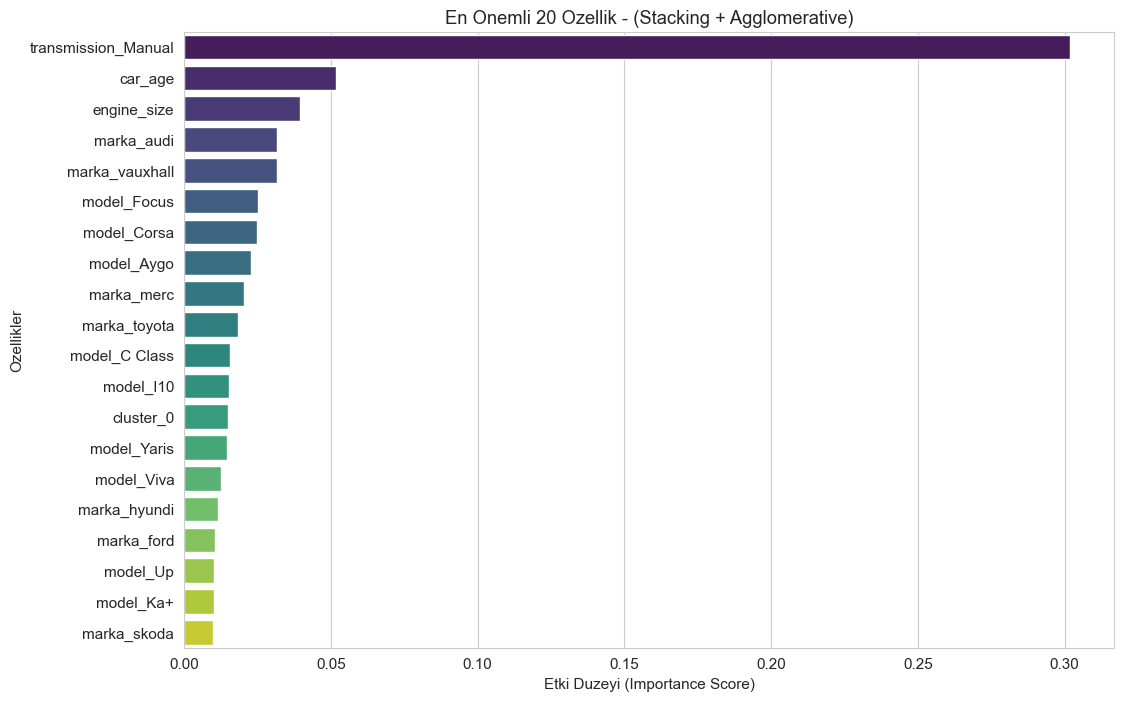


-> Analiz Tamamlandi: En etkili faktorler yukaridaki grafikte gosterilmistir.


In [12]:
def plot_feature_importance(pipeline, strategy_name):
    print(f"\n-> '{strategy_name}' icin Feature Importance analizi yapiliyor...")
    
    # 1. Pipeline icindeki parcalara erisim
    preprocessor = pipeline.named_steps['prep']
    stacking_model = pipeline.named_steps['reg']
    
    # 2. Ozellik Isimlerini (Feature Names) Dinamik Olarak Cikarma
    feature_names = []
    
    # A) Sayisal Ozellikler
    feature_names.extend(numeric_features)
    
    # B) Kategorik Ozellikler (OneHotEncoder icinden cekiyoruz)
    try:
        cat_ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
        feature_names.extend(cat_ohe.get_feature_names_out(categorical_features))
    except:
        # Eski surum sklearn veya erisim hatasi olursa yedek plan
        print("Uyari: Kategorik isimler otomatik alinamadi, manuel ekleniyor.")
    
    # C) Kumeleme Ozellikleri (HATANIN DUZELDIGI YER)
    if strategy_name != "Base Stacking":
        try:
            # Cluster pipeline icindeki OneHotEncoder'a ulasiyoruz
            cluster_pipe = preprocessor.named_transformers_['clusters']
            cluster_ohe = cluster_pipe.named_steps['ohe']
            # OHE, 6 kume icin 6 isim uretiyor, onlari aliyoruz
            cluster_features = cluster_ohe.get_feature_names_out(['cluster'])
            feature_names.extend(cluster_features)
        except Exception as e:
            print(f"Uyari: Cluster isimleri alinamadi. ({e})")

    # Isimleri temizle (orn: "num__mileage" -> "mileage")
    clean_names = [name.split('__')[-1] for name in feature_names]
    
    # 3. Onem Skorlarini Cekme (XGBoost estimator'i referans alinir)
    xgb_base_model = stacking_model.estimators_[0] 
    importances = xgb_base_model.feature_importances_
    
    # UZUNLUK KONTROLU (Mükemmeliyetçi Güvenlik Önlemi)
    if len(clean_names) != len(importances):
        print(f"DIKKAT: Isim sayisi ({len(clean_names)}) ile Skor sayisi ({len(importances)}) uyusmuyor!")
        # Hata vermemesi icin kesme yapiyoruz (Gecici cozum)
        min_len = min(len(clean_names), len(importances))
        clean_names = clean_names[:min_len]
        importances = importances[:min_len]

    # 4. DataFrame Olusturma ve Siralama
    fi_df = pd.DataFrame({
        'Ozellik': clean_names,
        'Onem': importances
    }).sort_values(by='Onem', ascending=False)
    
    # Ilk 20 Ozelligi Al
    top_20 = fi_df.head(20)
    
    # 5. Gorsellestirme
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Onem', y='Ozellik', data=top_20, palette='viridis', hue='Ozellik', legend=False)
    plt.title(f'En Onemli 20 Ozellik - ({strategy_name})')
    plt.xlabel('Etki Duzeyi (Importance Score)')
    plt.ylabel('Ozellikler')
    plt.show()
    
    return top_20

# SAMPIYON MODELI TEKRAR EGITIP ANALIZ ETME
# En iyi stratejiyi belirle (None, 'kmeans' veya 'agglomerative')
print(f"\n-> Sampiyon Model ({best_scenario}) icin Ozellik Analizi Baslatiliyor...")

if "Base" in best_scenario:
    best_strat = None
elif "Kmeans" in best_scenario:
    best_strat = 'kmeans'
else:
    best_strat = 'agglomerative'

# Modeli tekrar kur ve egit (Analiz icin)
final_pipe = get_stacking_pipeline(strategy=best_strat)
final_pipe.fit(X_train, y_train)

# Grafigi Ciz
importance_df = plot_feature_importance(final_pipe, best_scenario)

print("\n-> Analiz Tamamlandi: En etkili faktorler yukaridaki grafikte gosterilmistir.")